In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
import pandas as pd
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy
import time
import torch.nn.functional as F
from tqdm import tqdm

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ FIX: set_default_tensor_type ใช้ไม่ได้กับ CUDA — ใช้ dtype=torch.float32 ตอนสร้าง tensor แทน

Using device: cpu


# ANN

In [46]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.hidden1 = nn.Linear(2, 128)
        self.hidden2 = nn.Linear(128, 128)
        self.hidden3 = nn.Linear(128, 128)
        self.hidden4 = nn.Linear(128, 128)  
        self.hidden5 = nn.Linear(128, 128)
        self.output = nn.Linear(128, 2)
    def forward(self, x):
        x = torch.tanh(self.hidden1(x))
        x = torch.tanh(self.hidden2(x))
        x = torch.tanh(self.hidden3(x))
        x = torch.tanh(self.hidden4(x))
        x = torch.tanh(self.hidden5(x))
        return self.output(x)  # return [u, v]
    # Define the problem domain using the given vertices

# Vertice

In [47]:
from matplotlib.path import Path
import numpy as np

R = 1.0  # Radius

verts = [
    (R, 0),      # Start (1,0)
    (4, 0),      # ขวาล่าง
    (4, 4),      # ขวาบน
    (0, 4),      # ซ้ายบน
    (0, R),      # ลงมาถึง (0,1)
    # Bezier approximation ของ arc 90°: control point ≈ (0, 0.5523), (0.5523, 0)
    (0, R * (1 - 0.5523)),   # (0, 0.4477) — control point 1
    (R * (1 - 0.5523), 0),   # (0.4477, 0) — control point 2
    (R, 0),                  # ปลาย arc กลับมา (1,0)
    (R, 0),                  # CLOSEPOLY
]

codes = [
    Path.MOVETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.CURVE4,   # arc ด้วย cubic bezier (ต้องการ 3 จุด)
    Path.CURVE4,
    Path.CURVE4,
    Path.CLOSEPOLY,
]

path = Path(verts, codes)

def in_domain(x, y):
    points = np.column_stack((x.cpu().numpy(), y.cpu().numpy()))
    return torch.tensor(path.contains_points(points), dtype=torch.bool, device=device)

# BC

In [48]:
def BC_bottom(x, y):
    tol = 1e-6
    return ((torch.abs(y - 0) < tol) & (x >= 1.0) & (x <= 4.0)).squeeze()  # ← เริ่มที่ x=1 (ตัด arc ออก)

def BC_left(x, y):
    tol = 1e-6
    return ((torch.abs(x - 0) < tol) & (y >= 1.0) & (y <= 4.0)).squeeze()  # ← เริ่มที่ y=1

def BC_top(x, y):
    tol = 1e-6
    return ((torch.abs(y - 4) < tol) & (x >= 0) & (x <= 4.0)).squeeze()   # ← x ถึง 4.0

def BC_right(x, y):
    tol = 1e-6
    return ((torch.abs(x - 4.0) < tol) & (y >= 0) & (y <= 4.0)).squeeze()  # ← x=4.0

def BC_curved(x, y):
    """ขอบโค้ง: จุดที่อยู่บน arc x²+y²=1, ช่วง 0°–90°"""
    tol = 0.005   # tolerance สำหรับเส้นโค้ง
    r = torch.sqrt(x**2 + y**2)
    return ((torch.abs(r - 1.0) < tol) & (x >= 0) & (y >= 0) & (x <= 1.0) & (y <= 1.0)).squeeze()

# BC Loss

In [49]:
# ============================================================
# Material & load constants  (single source of truth)
# ============================================================
E   = 20.0  # Young's modulus [MPa]
nu  = 0.3   # Poisson's ratio
R   = 1.0   # Tunnel radius [m]

# Plane-Strain constitutive pre-factors (global, used in plot_results)
C11 = E * (1 - nu) / ((1 + nu) * (1 - 2 * nu))
C12 = E * nu       / ((1 + nu) * (1 - 2 * nu))
C33 = E            / (2 * (1 + nu))

# Distributed load on top edge
LOAD_X0  = 0
LOAD_X1  = 4.0
LOAD_VAL = -0.120  # [MPa]


def _stress_from_grad(xy_pts, net, E, nu):
    """Compute plane-strain stresses. E and nu passed explicitly for inverse problem."""
    C11_ = E * (1 - nu) / ((1 + nu) * (1 - 2 * nu))
    C12_ = E * nu       / ((1 + nu) * (1 - 2 * nu))
    C33_ = E            / (2 * (1 + nu))

    out  = net(xy_pts)
    u, v = out[:, 0:1], out[:, 1:2]
    grads_u = torch.autograd.grad(u.sum(), xy_pts, create_graph=True)[0]
    grads_v = torch.autograd.grad(v.sum(), xy_pts, create_graph=True)[0]
    u_x, u_y = grads_u[:, 0], grads_u[:, 1]
    v_x, v_y = grads_v[:, 0], grads_v[:, 1]
    s_xx = C11_ * u_x + C12_ * v_y
    s_yy = C12_ * u_x + C11_ * v_y
    s_xy = C33_ * (u_y + v_x)
    return s_xx, s_yy, s_xy


# ============================================================
# PDE residual (plane-strain equilibrium)  -- FIX: was missing entirely
# ============================================================
def PDE(x_pts, y_pts, net, E, nu):
    """Returns (loss_x, loss_y) equilibrium residual losses."""
    xy = torch.stack([x_pts, y_pts], dim=1).requires_grad_(True)
    s_xx, s_yy, s_xy = _stress_from_grad(xy, net, E, nu)

    dsxx_dx = torch.autograd.grad(s_xx.sum(), xy, create_graph=True)[0][:, 0]
    dsxy_dy = torch.autograd.grad(s_xy.sum(), xy, create_graph=True)[0][:, 1]
    dsyy_dy = torch.autograd.grad(s_yy.sum(), xy, create_graph=True)[0][:, 1]
    dsxy_dx = torch.autograd.grad(s_xy.sum(), xy, create_graph=True)[0][:, 0]

    res_x = dsxx_dx + dsxy_dy   # d(sigma_xx)/dx + d(sigma_xy)/dy = 0
    res_y = dsxy_dx + dsyy_dy   # d(sigma_xy)/dx + d(sigma_yy)/dy = 0

    loss_x = F.mse_loss(res_x, torch.zeros_like(res_x))
    loss_y = F.mse_loss(res_y, torch.zeros_like(res_y))
    return loss_x, loss_y


# ============================================================
# BC Loss -- FIX: now accepts E, nu for consistent stress computation
# ============================================================
def BC(xy, net, E, nu):
    """
    Boundary-condition loss for the quarter-domain with a circular cutout.

    Boundaries
    ----------
    Bottom  (y=0, x in [R,4])  : v = 0, s_xy = 0
    Left    (x=0, y in [R,4])  : u = 0, s_xy = 0  (symmetry)
    Right   (x=4, y in [0,4])  : u = 0, s_xy = 0  (symmetry)
    Top     (y=4, x in [0,4])  : s_xy = 0; s_yy = LOAD_VAL or 0
    Curved  (x^2+y^2=R^2)      : traction-free
    """
    x = xy[:, 0].unsqueeze(1)
    y = xy[:, 1].unsqueeze(1)

    out = net(xy)
    u   = out[:, 0:1]
    v   = out[:, 1:2]

    bc_b = BC_bottom(x, y)
    bc_l = BC_left  (x, y)
    bc_r = BC_right (x, y)
    bc_t = BC_top   (x, y)
    bc_c = BC_curved(x, y)

    loss = torch.tensor(0.0, device=xy.device)

    # Bottom: v = 0, s_xy = 0
    if bc_b.any():
        loss += F.mse_loss(v[bc_b], torch.zeros_like(v[bc_b]))
        xy_b = xy[bc_b].detach().requires_grad_(True)
        _, _, s_xy_b = _stress_from_grad(xy_b, net, E, nu)
        loss += F.mse_loss(s_xy_b, torch.zeros_like(s_xy_b))

    # Left: u = 0, s_xy = 0 (symmetry)
    if bc_l.any():
        loss += F.mse_loss(u[bc_l], torch.zeros_like(u[bc_l]))
        xy_l = xy[bc_l].detach().requires_grad_(True)
        _, _, s_xy_l = _stress_from_grad(xy_l, net, E, nu)
        loss += F.mse_loss(s_xy_l, torch.zeros_like(s_xy_l))

    # Right: u = 0, s_xy = 0 (symmetry)
    if bc_r.any():
        loss += F.mse_loss(u[bc_r], torch.zeros_like(u[bc_r]))
        xy_r = xy[bc_r].detach().requires_grad_(True)
        _, _, s_xy_r = _stress_from_grad(xy_r, net, E, nu)
        loss += F.mse_loss(s_xy_r, torch.zeros_like(s_xy_r))

    # Top: mixed Neumann
    if bc_t.any():
        xy_t = xy[bc_t].detach().requires_grad_(True)
        x_t  = xy_t[:, 0]
        s_xx_t, s_yy_t, s_xy_t = _stress_from_grad(xy_t, net, E, nu)

        loss += F.mse_loss(s_xy_t, torch.zeros_like(s_xy_t))

        load_mask    = (x_t >= LOAD_X0) & (x_t <= LOAD_X1)
        no_load_mask = ~load_mask

        if no_load_mask.any():
            loss += F.mse_loss(s_yy_t[no_load_mask],
                               torch.zeros_like(s_yy_t[no_load_mask]))
        if load_mask.any():
            loss += F.mse_loss(s_yy_t[load_mask],
                               LOAD_VAL * torch.ones_like(s_yy_t[load_mask]))

    # Curved wall: traction-free
    if bc_c.any():
        xy_c = xy[bc_c].detach().requires_grad_(True)
        x_c  = xy_c[:, 0]
        y_c  = xy_c[:, 1]
        r_c  = torch.sqrt(x_c**2 + y_c**2).clamp(min=1e-8)
        nx_c = x_c / r_c
        ny_c = y_c / r_c

        s_xx_c, s_yy_c, s_xy_c = _stress_from_grad(xy_c, net, E, nu)

        t_x = s_xx_c * nx_c + s_xy_c * ny_c
        t_y = s_xy_c * nx_c + s_yy_c * ny_c

        loss += F.mse_loss(t_x, torch.zeros_like(t_x))
        loss += F.mse_loss(t_y, torch.zeros_like(t_y))

    return loss


# Data Sampling

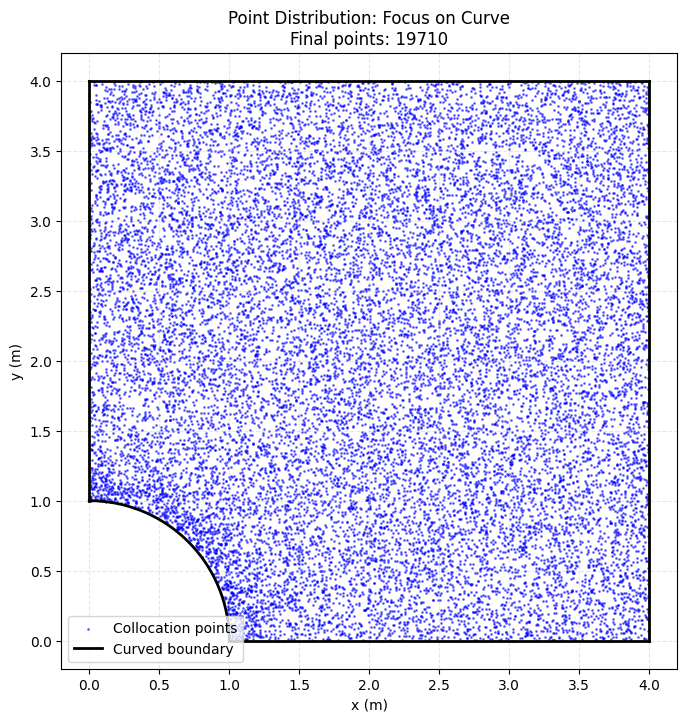

In [50]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def generate_point_distribution(nx=100, ny=100, arc_density=20, arc_influence=0.8, plot=False):
    x_min, x_max = 0.0, 4.0
    y_min, y_max = 0.0, 4.0
    R = 1.0

    num_random_points = nx * ny * 5
    x_random = torch.rand(num_random_points, device=device) * (x_max - x_min) + x_min
    y_random = torch.rand(num_random_points, device=device) * (y_max - y_min) + y_min

    dist_from_origin = torch.sqrt(x_random**2 + y_random**2)
    in_corner_zone = (x_random < R) & (y_random < R)
    invalid_mask = in_corner_zone & (dist_from_origin < R)

    valid_mask = ~invalid_mask
    x_random = x_random[valid_mask]
    y_random = y_random[valid_mask]
    dist_from_origin = dist_from_origin[valid_mask]

    dist_to_arc = torch.abs(dist_from_origin - R)

    arc_weight_mask = (x_random < R * 1.5) & (y_random < R * 1.5)
    not_on_arc = dist_to_arc > 0.01

    base_prob = 0.4
    prob_arc = arc_influence / (1 + (dist_to_arc * arc_density) ** 2)
    prob_arc = prob_arc * arc_weight_mask.float() * not_on_arc.float()

    keep_prob = torch.clamp(base_prob + prob_arc, 0, 1)

    keep_mask = torch.rand(len(x_random), device=device) < keep_prob
    x_final = x_random[keep_mask]
    y_final = y_random[keep_mask]

    # ✅ FIX: plot แยกออกมา ไม่ plot ทุกครั้งที่เรียก (ทำให้ training ช้ามากบน CUDA)
    if plot:
        plt.figure(figsize=(8, 8))
        plt.scatter(x_final.cpu().numpy(), y_final.cpu().numpy(),
                    s=1, color='blue', alpha=0.5, label='Collocation points')
        theta_arc = np.linspace(0, np.pi / 2, 100)
        plt.plot(R * np.cos(theta_arc), R * np.sin(theta_arc), 'k-', linewidth=2, label='Curved boundary')
        plt.plot([R, x_max], [0, 0], 'k-', linewidth=2)
        plt.plot([x_max, x_max], [0, y_max], 'k-', linewidth=2)
        plt.plot([x_max, 0], [y_max, y_max], 'k-', linewidth=2)
        plt.plot([0, 0], [y_max, R], 'k-', linewidth=2)
        plt.xlabel('x (m)')
        plt.ylabel('y (m)')
        plt.title(f'Point Distribution: Focus on Curve\nFinal points: {len(x_final)}')
        plt.gca().set_aspect('equal')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.show()

    return x_final, y_final

# ดู plot ครั้งเดียวก่อน train
x_pts, y_pts = generate_point_distribution(arc_density=10, arc_influence=1.2, plot=True)

# Load data

In [51]:
def load_data(filename, device):
    """Loads data from CSV file for inverse PINN training."""
    try:
        data = pd.read_csv(filename)
    except FileNotFoundError:
        print(f"Error: Data file '{filename}' not found.")
        return None

    # --- 1. Process Displacement Data ---
    disp_cols = ['X', 'Y', 'ux', 'uy']
    if not all(col in data.columns for col in disp_cols):
        print(f"Error: Missing displacement columns. Need: {', '.join(disp_cols)}")
        return None

    disp_data = data[disp_cols].dropna()
    if len(disp_data) == 0:
        print("Error: No valid displacement data found.")
        return None

    X_disp = torch.tensor(disp_data['X'].values, dtype=torch.float32).unsqueeze(1).to(device)
    Y_disp = torch.tensor(disp_data['Y'].values, dtype=torch.float32).unsqueeze(1).to(device)
    xy_disp_data = torch.cat([X_disp, Y_disp], dim=1)
    u_data = torch.tensor(disp_data['ux'].values, dtype=torch.float32).unsqueeze(1).to(device)
    v_data = torch.tensor(disp_data['uy'].values, dtype=torch.float32).unsqueeze(1).to(device)
    print(f"Loaded {len(xy_disp_data)} displacement data points.")

    # --- 2. Process Stress Data ---
    stress_cols = ['stress_xx', 'stress_yy', 'stress_xy']
    required_stress = ['X', 'Y'] + stress_cols
    if not all(col in data.columns for col in required_stress):
        print(f"Error: Missing stress columns. Need: {', '.join(required_stress)}")
        return None

    stress_data = data[required_stress].dropna()
    if len(stress_data) == 0:
        print("Error: No valid stress data found.")
        return None

    # FIX: xy_stress_data was never defined in original code
    X_stress = torch.tensor(stress_data['X'].values, dtype=torch.float32).unsqueeze(1).to(device)
    Y_stress = torch.tensor(stress_data['Y'].values, dtype=torch.float32).unsqueeze(1).to(device)
    xy_stress_data = torch.cat([X_stress, Y_stress], dim=1)

    # Convert stresses from kPa (data) to MPa (model unit)
    s_xx_data = torch.tensor(stress_data['stress_xx'].values / 1000.0, dtype=torch.float32).unsqueeze(1).to(device)
    s_yy_data = torch.tensor(stress_data['stress_yy'].values / 1000.0, dtype=torch.float32).unsqueeze(1).to(device)
    s_xy_data = torch.tensor(stress_data['stress_xy'].values / 1000.0, dtype=torch.float32).unsqueeze(1).to(device)
    print(f"Loaded {len(xy_stress_data)} stress data points.")

    return xy_disp_data, u_data, v_data, xy_stress_data, s_xx_data, s_yy_data, s_xy_data


# Data loss

In [52]:
def data_loss(net, xy_disp_data, u_data, v_data, xy_stress_data,
              s_xx_data, s_yy_data, s_xy_data, E, nu):
    """Calculates MSE loss from displacement and stress datasets."""

    # --- 1. Displacement Loss ---
    output_disp = net(xy_disp_data)
    u_pred = output_disp[:, 0:1]
    v_pred = output_disp[:, 1:2]
    loss_u = F.mse_loss(u_pred, u_data)
    loss_v = F.mse_loss(v_pred, v_data)

    # --- 2. Stress Loss ---
    # FIX: detach then requires_grad so autograd graph is clean each call
    xy_stress = xy_stress_data.detach().requires_grad_(True)
    output_stress = net(xy_stress)
    u_stress = output_stress[:, 0:1]
    v_stress = output_stress[:, 1:2]

    u_x = torch.autograd.grad(u_stress.sum(), xy_stress, create_graph=True)[0][:, 0].unsqueeze(1)
    u_y = torch.autograd.grad(u_stress.sum(), xy_stress, create_graph=True)[0][:, 1].unsqueeze(1)
    v_x = torch.autograd.grad(v_stress.sum(), xy_stress, create_graph=True)[0][:, 0].unsqueeze(1)
    v_y = torch.autograd.grad(v_stress.sum(), xy_stress, create_graph=True)[0][:, 1].unsqueeze(1)

    # Plane-strain constitutive law
    C1 = E / ((1 + nu) * (1 - 2 * nu))
    s_xx_pred = C1 * ((1 - nu) * u_x + nu * v_y)
    s_yy_pred = C1 * (nu * u_x + (1 - nu) * v_y)
    s_xy_pred = E / (2 * (1 + nu)) * (u_y + v_x)

    loss_s_xx = F.mse_loss(s_xx_pred, s_xx_data)
    loss_s_yy = F.mse_loss(s_yy_pred, s_yy_data)
    loss_s_xy = F.mse_loss(s_xy_pred, s_xy_data)

    # --- 3. Total Data Loss ---
    total_data_loss = loss_u + loss_v + loss_s_xx + loss_s_yy + loss_s_xy
    return total_data_loss


# Train

In [53]:
from tqdm import tqdm  # เพิ่มถ้ายังไม่มี

def train(net, optimizer_net, optimizer_material, E_param, nu_param, data_tensors, n_epochs, data_loss_weight=1.0, nx=100, ny=100):
    scheduler_net = CosineAnnealingLR(optimizer_net, T_max=n_epochs, eta_min=1e-4)
    scheduler_material = CosineAnnealingLR(optimizer_material, T_max=n_epochs, eta_min=1e-2)

    best_loss = float('inf')

    loss_history = []
    pde_x_history = []
    pde_y_history = []
    bc_history = []
    data_history = []
    epoch_history = []
    E_history = []
    nu_history = []

    print("Generating training points...")
    x_inner, y_inner = generate_point_distribution(nx=nx, ny=ny, plot=False)  # ✅ FIX: ไม่ plot ใน loop
    print(f"Generated {len(x_inner)} interior points")

    print("Generating boundary points...")
    num_boundary_points = 1000

    x_bottom = torch.linspace(1.0, 4.0, num_boundary_points, device=device)
    y_bottom = torch.zeros(num_boundary_points, device=device)

    x_left = torch.zeros(num_boundary_points, device=device)
    y_left = torch.linspace(1.0, 4.0, num_boundary_points, device=device)

    x_top = torch.linspace(0, 4.0, num_boundary_points, device=device)
    y_top = torch.ones(num_boundary_points, device=device) * 4

    x_right = torch.ones(num_boundary_points, device=device) * 4.0
    y_right = torch.linspace(0, 4.0, num_boundary_points, device=device)

    theta = torch.linspace(0, torch.pi/2, num_boundary_points, device=device)
    x_curve = torch.cos(theta)
    y_curve = torch.sin(theta)

    x_b = torch.cat([x_bottom, x_left, x_top, x_right, x_curve])
    y_b = torch.cat([y_bottom, y_left, y_top, y_right, y_curve])

    xy_b = torch.stack([x_b, y_b], dim=1)
    print(f"Generated {len(xy_b)} boundary points")

    # ✅ FIX: unpack data_tensors (สาเหตุ NameError เดิม)
    xy_disp_data, u_data, v_data, xy_stress_data, s_xx_data, s_yy_data, s_xy_data = data_tensors

    print(f"Starting training for {n_epochs} epochs...")

    pbar = tqdm(range(n_epochs), desc="Training PINN", unit="epoch")
    start_time = time.time()

    for epoch in pbar:
        optimizer_net.zero_grad()
        optimizer_material.zero_grad()

        E = F.softplus(E_param) + 1.0
        nu = 0.01 + 0.48 * torch.sigmoid(nu_param)

        loss_pde_x, loss_pde_y = PDE(x_inner, y_inner, net, E, nu)
        loss_pde = loss_pde_x + loss_pde_y

        loss_bc = BC(xy_b, net, E, nu)

        loss_data = data_loss(net,
                              xy_disp_data, u_data, v_data,
                              xy_stress_data, s_xx_data, s_yy_data, s_xy_data,
                              E, nu)

        loss = loss_pde + loss_bc + data_loss_weight * loss_data

        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=0.5)
        torch.nn.utils.clip_grad_norm_([E_param, nu_param], max_norm=0.1)

        optimizer_net.step()
        optimizer_material.step()
        scheduler_net.step()
        scheduler_material.step()

        loss_history.append(loss.item())
        pde_x_history.append(loss_pde_x.item())
        pde_y_history.append(loss_pde_y.item())
        bc_history.append(loss_bc.item())
        data_history.append(loss_data.item())
        epoch_history.append(epoch + 1)
        E_history.append(E.item())
        nu_history.append(nu.item())

        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save({
                'net_state_dict': net.state_dict(),
                'optimizer_net_state_dict': optimizer_net.state_dict(),
                'optimizer_material_state_dict': optimizer_material.state_dict(),
                'scheduler_net_state_dict': scheduler_net.state_dict(),
                'scheduler_material_state_dict': scheduler_material.state_dict(),
                'E_param': E_param.item(),
                'nu_param': nu_param.item(),
                'E_final': E.item(),
                'nu_final': nu.item(),
                'loss': loss.item(),
                'epoch': epoch,
            }, 'best_model_inverse.pth')

        if (epoch + 1) % 100 == 0:
            elapsed_time = time.time() - start_time
            pbar.write(f'Epoch {epoch+1}/{n_epochs} | Loss: {loss.item():.6e} | '
                       f'PDE: {loss_pde.item():.6e} | BC: {loss_bc.item():.6e} | '
                       f'Data: {loss_data.item():.6e} | '
                       f'E: {E.item():.4f} MPa | nu: {nu.item():.4f} | '
                       f'Time: {elapsed_time:.2f}s')
            start_time = time.time()

    # Save CSV
    training_df = pd.DataFrame({
        'Epoch': epoch_history,
        'Total_Loss': loss_history,
        'PDE_x_Loss': pde_x_history,
        'PDE_y_Loss': pde_y_history,
        'BC_Loss': bc_history,
        'Data_Loss': data_history,
        'E_MPa': E_history,
        'nu': nu_history,
        'Learning_Rate_Net': [scheduler_net.get_last_lr()[0]] * len(epoch_history),
        'Learning_Rate_Material': [scheduler_material.get_last_lr()[0]] * len(epoch_history)
    })
    training_df.to_csv('training_history.csv', index=False)
    print("Training history saved to training_history.csv")

    # Plot loss history
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(epoch_history, loss_history, 'b-', label='Total Loss')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss History')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(epoch_history, pde_x_history, 'r-', label='PDE_x Loss')
    plt.plot(epoch_history, pde_y_history, 'g-', label='PDE_y Loss')
    plt.plot(epoch_history, bc_history, 'b-', label='BC Loss')
    plt.plot(epoch_history, data_history, 'm-', label=f'Data Loss (x{data_loss_weight})')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Component Losses (log scale)')
    plt.title('Component Losses History')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('loss_history_inverse.png')
    plt.close()

    # Plot material parameters
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epoch_history, E_history, 'b-', linewidth=1.5, label='Predicted E')
    plt.axhline(y=15, color='k', linestyle='--', linewidth=1.2, label='True E = 15 MPa')
    plt.xlabel('Epoch')
    plt.ylabel("Young's Modulus E (MPa)")
    plt.title('Evolution of E during Training')
    plt.grid(False)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epoch_history, nu_history, 'r-', linewidth=1.5, label='Predicted ν')
    plt.axhline(y=0.3, color='k', linestyle='--', linewidth=1.2, label='True ν = 0.3')
    plt.xlabel('Epoch')
    plt.ylabel("Poisson's Ratio ν")
    plt.title('Evolution of ν during Training')
    plt.grid(False)
    plt.legend()
    plt.tight_layout()
    plt.savefig('material_parameters_evolution.png')
    plt.close()
    print("Material parameters evolution plot saved to material_parameters_evolution.png")

    metrics = {
        'loss_history': loss_history,
        'pde_x_history': pde_x_history,
        'pde_y_history': pde_y_history,
        'bc_history': bc_history,
        'data_history': data_history,
        'epoch_history': epoch_history,
        'E_history': E_history,
        'nu_history': nu_history
    }

    print("Loading best model from 'best_model_inverse.pth'")
    # ✅ FIX: map_location=device เพื่อโหลด checkpoint ให้ตรง CUDA/CPU
    checkpoint = torch.load('best_model_inverse.pth', map_location=device)
    net.load_state_dict(checkpoint['net_state_dict'])
    final_E = checkpoint['E_final']
    final_nu = checkpoint['nu_final']

    print("Training completed.")
    return net, metrics, final_E, final_nu

# Plot Results

In [54]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge

def plot_results(net, E_val=20.0, nu_val=0.3, output_filename='Deep_Tunnel_results.csv'):
    nx_plot, ny_plot = 200, 200
    X_lin = torch.linspace(0, 4.0, nx_plot, device=device)
    Y_lin = torch.linspace(0, 4.0, ny_plot, device=device)

    xx, yy = torch.meshgrid(X_lin, Y_lin, indexing='ij')
    X_flat, Y_flat = xx.flatten(), yy.flatten()

    mask    = in_domain(X_flat, Y_flat)
    mask_np = mask.cpu().numpy()

    XY = torch.stack([X_flat, Y_flat], dim=1)
    XY.requires_grad_(True)

    # FIX: use identified E_val, nu_val instead of global constants
    C11_p = E_val * (1 - nu_val) / ((1 + nu_val) * (1 - 2 * nu_val))
    C12_p = E_val * nu_val       / ((1 + nu_val) * (1 - 2 * nu_val))
    C33_p = E_val                / (2 * (1 + nu_val))

    with torch.enable_grad():
        out  = net(XY)
        U, V = out[:, 0:1], out[:, 1:2]
        grads_U = torch.autograd.grad(U.sum(), XY, create_graph=True)[0]
        grads_V = torch.autograd.grad(V.sum(), XY, create_graph=True)[0]
        U_x, U_y = grads_U[:, 0], grads_U[:, 1]
        V_x, V_y = grads_V[:, 0], grads_V[:, 1]
        sigma_xx = C11_p * U_x + C12_p * V_y
        sigma_yy = C12_p * U_x + C11_p * V_y
        sigma_xy = C33_p * (U_y + V_x)

    X_np      = X_flat.detach().cpu().numpy()
    Y_np      = Y_flat.detach().cpu().numpy()
    U_np      = U.detach().cpu().numpy().squeeze()
    V_np      = V.detach().cpu().numpy().squeeze()
    sxx_np    = sigma_xx.detach().cpu().numpy() * 1000
    syy_np    = sigma_yy.detach().cpu().numpy() * 1000
    sxy_np    = sigma_xy.detach().cpu().numpy() * 1000
    magnitude = np.sqrt(U_np**2 + V_np**2)

    pd.DataFrame({
        'X': X_np[mask_np], 'Y': Y_np[mask_np],
        'ux': U_np[mask_np], 'uy': V_np[mask_np],
        'sigma_xx': sxx_np[mask_np], 'sigma_yy': syy_np[mask_np],
        'sigma_xy': sxy_np[mask_np], 'magnitude': magnitude[mask_np],
    }).to_csv(output_filename, index=False)
    print(f'Results saved to {output_filename}')

    X_1d = X_lin.cpu().numpy()
    Y_1d = Y_lin.cpu().numpy()

    def get_plot_array(arr):
        arr_2d  = arr.reshape(nx_plot, ny_plot)
        mask_2d = mask_np.reshape(nx_plot, ny_plot)
        return np.ma.masked_array(arr_2d.T, mask=~mask_2d.T)

    fields = [
        (U_np,      'Displacement u_x [m]',    'ux'),
        (V_np,      'Displacement u_y [m]',    'uy'),
        (magnitude, 'Displacement |u| [m]',    '|u|'),
        (sxx_np,    'Normal stress σ_xx [kPa]','σxx'),
        (syy_np,    'Normal stress σ_yy [kPa]','σyy'),
        (sxy_np,    'Shear stress σ_xy [kPa]', 'σxy'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    for ax, (arr, label, title) in zip(axes.flatten(), fields):
        pcm = ax.pcolormesh(
            X_1d, Y_1d,
            get_plot_array(arr),
            shading='auto', cmap='jet'
        )
        fig.colorbar(pcm, ax=ax, label=label)
        ax.set_title(title)
        ax.set_xlabel('X [m]')
        ax.set_ylabel('Y [m]')
        ax.set_aspect('equal')

        # ── Wedge ปิดบังพื้นที่ภายในอุโมงค์ (สีขาว) ─────────────────────
        tunnel_patch = Wedge(
            center=(0, 0), r=R,
            theta1=0, theta2=90,
            facecolor='white', edgecolor='none', zorder=5
        )
        ax.add_patch(tunnel_patch)

        # ── เส้นขอบ domain ────────────────────────────────────────────────
        theta_arc = np.linspace(0, np.pi/2, 300)
        ax.plot(R*np.cos(theta_arc), R*np.sin(theta_arc), 'k-', lw=1.5, zorder=6)
        ax.plot([R, 4], [0, 0], 'k-', lw=1, zorder=6)
        ax.plot([4, 4], [0, 4], 'k-', lw=1, zorder=6)
        ax.plot([4, 0], [4, 4], 'k-', lw=1, zorder=6)
        ax.plot([0, 0], [4, R], 'k-', lw=1, zorder=6)

        ax.set_xlim(0, 4)
        ax.set_ylim(0, 4)

    plt.suptitle('PINN Results — Deep Tunnel (Plane Strain)', fontsize=14)
    plt.tight_layout()
    plt.savefig('results_plots.png', dpi=300, bbox_inches='tight')
    plt.close()
    print('Result plots saved to results_plots.png')


# Main Execution

In [55]:
# ✅ FIX: ใน Jupyter ไม่ต้องใช้ if __name__ == "__main__"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Load Data ---
data_filename = 'Clay_analysis_FEM.csv'
data_tensors = load_data(data_filename, device)

if data_tensors is not None:
    print(f"Successfully loaded {len(data_tensors[0])} data points from {data_filename}")

    # --- 2. Initialize network ---
    net = Net().to(device)

    initial_E_param = torch.tensor([-10.0], device=device, requires_grad=True)
    initial_nu_param = torch.tensor([-1.466], device=device, requires_grad=True)

    print(f"Initial E guess: {(F.softplus(initial_E_param) + 1.0).item():.4f} MPa")
    print(f"Initial nu guess: {(0.01 + 0.48 * torch.sigmoid(initial_nu_param)).item():.4f}")

    # --- 3. Optimizer ---
    optimizer_net = optim.Adam(net.parameters(), lr=0.001)
    optimizer_material = optim.Adam([initial_E_param, initial_nu_param], lr=0.05)

    # --- 4. Train ---
    data_weight = 300.0

    trained_net, metrics, final_E, final_nu = train(
        net=net,
        optimizer_net=optimizer_net,
        optimizer_material=optimizer_material,
        E_param=initial_E_param,
        nu_param=initial_nu_param,
        data_tensors=data_tensors,
        n_epochs=100,          # เพิ่มเป็น 20000–50000 สำหรับ production
        data_loss_weight=data_weight,
        nx=100,
        ny=100
    )

    print("\n--- Inverse Analysis Complete ---")
    print(f"Estimated Young's Modulus (E): {final_E:.4f} MPa")
    print(f"Estimated Poisson's Ratio (nu): {final_nu:.4f}")

    # --- 5. Plot results ---
    try:
        plot_results(trained_net, final_E, final_nu)
    except Exception as e:
        print(f"Error in plot_results: {str(e)}")
else:
    print("Exiting due to data loading error.")

Using device: cpu
Loaded 2932 displacement data points.
Loaded 2932 stress data points.
Successfully loaded 2932 data points from Clay_analysis_FEM.csv
Initial E guess: 1.0000 MPa
Initial nu guess: 0.1000
Generating training points...
Generated 19051 interior points
Generating boundary points...
Generated 5000 boundary points
Starting training for 100 epochs...


















Training PINN:  15%|█▌        | 15/100 [00:23<02:15,  1.60s/epoch]


KeyboardInterrupt: 